In [1]:
import pandas as pd
import numpy as np


In [2]:
import pandas as pd
import numpy as np

np.random.seed(42)

n_users = 20000

genres = [
    "rock","pop","hiphop","electronic","jazz",
    "classical","latin","country","afrobeats","amapiano"
]

data = []

for i in range(n_users):

    archetype = np.random.choice([
        "power_listener",
        "genre_loyalist",
        "explorer",
        "casual_listener",
        "low_engagement"
    ])

    genre_minutes = {}

    if archetype == "power_listener":
        total_minutes = np.random.randint(15000,30000)
        sessions = np.random.uniform(3,6)
        skip_rate = np.random.uniform(0.01,0.08)
        playlists = np.random.randint(10,30)

        weights = np.random.dirichlet(np.ones(len(genres)))

    elif archetype == "genre_loyalist":
        total_minutes = np.random.randint(6000,12000)
        sessions = np.random.uniform(2,4)
        skip_rate = np.random.uniform(0.05,0.15)
        playlists = np.random.randint(5,15)

        weights = np.zeros(len(genres))
        favorite = np.random.randint(0,len(genres))
        weights[favorite] = 0.9
        weights += np.random.dirichlet(np.ones(len(genres)))*0.1

    elif archetype == "explorer":
        total_minutes = np.random.randint(8000,16000)
        sessions = np.random.uniform(2,5)
        skip_rate = np.random.uniform(0.05,0.12)
        playlists = np.random.randint(8,20)

        weights = np.random.dirichlet(np.ones(len(genres))*3)

    elif archetype == "casual_listener":
        total_minutes = np.random.randint(1000,5000)
        sessions = np.random.uniform(0.5,2)
        skip_rate = np.random.uniform(0.2,0.35)
        playlists = np.random.randint(0,5)

        weights = np.random.dirichlet(np.ones(len(genres)))

    else:
        total_minutes = np.random.randint(200,1500)
        sessions = np.random.uniform(0.2,1)
        skip_rate = np.random.uniform(0.3,0.5)
        playlists = np.random.randint(0,2)

        weights = np.random.dirichlet(np.ones(len(genres)))

    minutes_distribution = weights * total_minutes

    row = dict(zip([g+"_minutes" for g in genres], minutes_distribution))
    row["sessions_per_day"] = sessions
    row["skip_rate"] = skip_rate
    row["playlists_created"] = playlists
    row["total_minutes"] = total_minutes

    data.append(row)

df = pd.DataFrame(data)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (20000, 14)


,rock_minutes,pop_minutes,hiphop_minutes,electronic_minutes,jazz_minutes,classical_minutes,latin_minutes,country_minutes,afrobeats_minutes,amapiano_minutes,sessions_per_day,skip_rate,playlists_created,total_minutes
0,31.206650,31.201392,11.008807,370.015186,169.087677,226.518610,3.826542,644.565223,328.657476,43.912436,0.775152,0.316954,4,1860
1,318.628962,193.938508,533.194351,84.643562,194.666726,257.070924,343.079595,866.487776,125.491503,406.798093,1.426222,0.291748,4,3324
2,160.281768,7085.936418,8031.802245,3937.305218,865.670795,244.905844,2746.864897,1382.285940,310.136947,1628.809927,5.579821,0.057622,18,26394
3,1582.951259,301.641295,2128.149347,1548.346462,1300.008707,1154.586849,1038.524669,2509.812159,1692.508306,1092.470947,3.173182,0.062757,11,14349
4,2584.498052,2749.975144,3107.083192,162.027708,934.922642,259.377611,4188.222594,2056.276541,846.307043,138.309473,3.880465,0.010986,28,17027


In [3]:
df.to_csv("spotify_listener_data.csv", index=False)

In [4]:
genres = [
    "rock","pop","hiphop","electronic","jazz",
    "classical","latin","country","afrobeats","amapiano"
]

for g in genres:
    df[g + "_pct"] = df[g + "_minutes"] / df["total_minutes"]

df.head()

,rock_minutes,pop_minutes,hiphop_minutes,electronic_minutes,jazz_minutes,classical_minutes,latin_minutes,country_minutes,afrobeats_minutes,amapiano_minutes,...,rock_pct,pop_pct,hiphop_pct,electronic_pct,jazz_pct,classical_pct,latin_pct,country_pct,afrobeats_pct,amapiano_pct
0,31.206650,31.201392,11.008807,370.015186,169.087677,226.518610,3.826542,644.565223,328.657476,43.912436,...,0.016778,0.016775,0.005919,0.198933,0.090907,0.121784,0.002057,0.346540,0.176698,0.023609
1,318.628962,193.938508,533.194351,84.643562,194.666726,257.070924,343.079595,866.487776,125.491503,406.798093,...,0.095857,0.058345,0.160407,0.025464,0.058564,0.077338,0.103213,0.260676,0.037753,0.122382
2,160.281768,7085.936418,8031.802245,3937.305218,865.670795,244.905844,2746.864897,1382.285940,310.136947,1628.809927,...,0.006073,0.268468,0.304304,0.149174,0.032798,0.009279,0.104072,0.052371,0.011750,0.061711
3,1582.951259,301.641295,2128.149347,1548.346462,1300.008707,1154.586849,1038.524669,2509.812159,1692.508306,1092.470947,...,0.110318,0.021022,0.148313,0.107906,0.090599,0.080465,0.072376,0.174912,0.117953,0.076136
4,2584.498052,2749.975144,3107.083192,162.027708,934.922642,259.377611,4188.222594,2056.276541,846.307043,138.309473,...,0.151788,0.161507,0.182480,0.009516,0.054908,0.015233,0.245975,0.120766,0.049704,0.008123


In [5]:
import numpy as np

genre_pct_cols = [g + "_pct" for g in genres]

df["genre_diversity"] = -np.sum(
    df[genre_pct_cols] * np.log(df[genre_pct_cols] + 1e-9),
    axis=1
)

print("Dataset shape:", df.shape)
df[["genre_diversity"]].head()

Dataset shape: (20000, 25)


,genre_diversity
0,1.737847
1,2.107356
2,1.799453
3,2.211188
4,1.946989


In [6]:


genre_pct_cols = [g + "_pct" for g in genres]

In [7]:
from sklearn.preprocessing import StandardScaler

cluster_features = genre_pct_cols + [
    "sessions_per_day",
    "skip_rate",
    "playlists_created",
    "total_minutes",
    "genre_diversity"
]

X = df[cluster_features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled feature matrix shape:", X_scaled.shape)

Scaled feature matrix shape: (20000, 15)


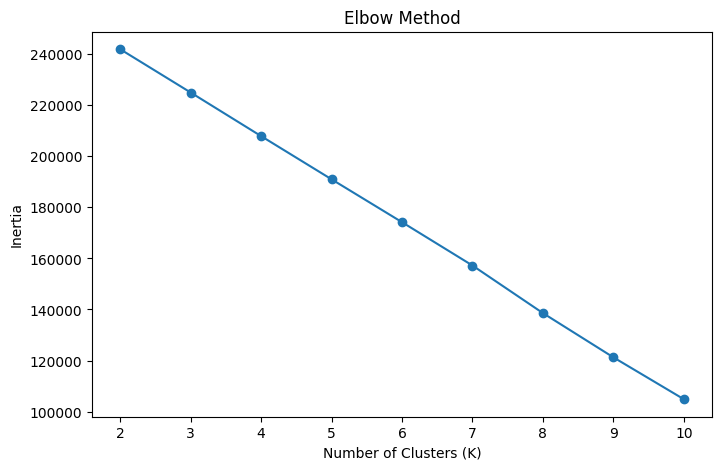

In [8]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot
plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

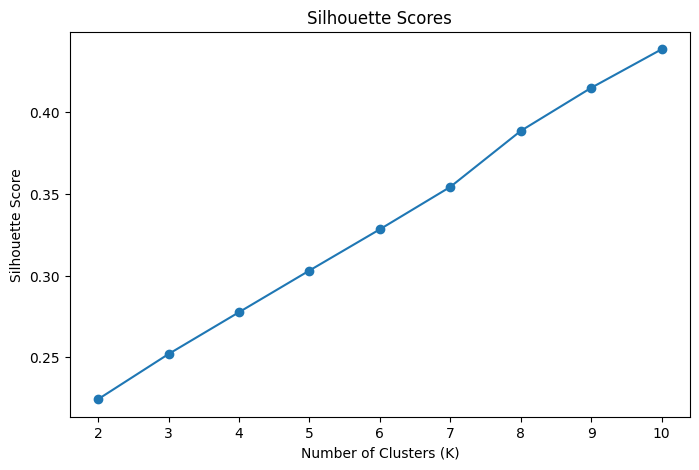

In [9]:
from sklearn.metrics import silhouette_score

sil_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)

# Plot
plt.figure(figsize=(8,5))
plt.plot(K_range, sil_scores, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores")
plt.show()

In [10]:
from sklearn.cluster import KMeans

kmeans_final = KMeans(n_clusters=5, random_state=42)

df["cluster"] = kmeans_final.fit_predict(X_scaled)

In [11]:
df["cluster"].value_counts()

cluster
1    10400
2     7961
0      797
3      424
4      418
Name: count, dtype: int64

In [12]:
cluster_profile = df.groupby("cluster")[
    ["total_minutes",
     "sessions_per_day",
     "skip_rate",
     "playlists_created",
     "genre_diversity"]
].mean()

cluster_profile

,total_minutes,sessions_per_day,skip_rate,playlists_created,genre_diversity
cluster,,,,,
0,9017.616060,3.011678,0.099276,9.542033,0.477269
1,15264.392019,3.764122,0.073384,14.821538,1.674231
2,1915.093456,0.919629,0.337435,1.252732,1.927956
3,8984.471698,2.997992,0.102575,9.143868,0.475638
4,9246.906699,2.966460,0.101586,9.399522,0.480315


In [13]:
from sklearn.cluster import KMeans

kmeans_4 = KMeans(n_clusters=4, random_state=42)

df["cluster_4"] = kmeans_4.fit_predict(X_scaled)

print(df["cluster_4"].value_counts())

df.groupby("cluster_4")[[
    "total_minutes",
    "sessions_per_day",
    "skip_rate",
    "playlists_created",
    "genre_diversity"
]].mean()

cluster_4
1    10815
2     7964
0      797
3      424
Name: count, dtype: int64


,total_minutes,sessions_per_day,skip_rate,playlists_created,genre_diversity
cluster_4,,,,,
0,9017.616060,3.011678,0.099276,9.542033,0.477269
1,15035.238650,3.734013,0.074411,14.615719,1.628176
2,1915.474259,0.919722,0.337422,1.252762,1.927738
3,8984.471698,2.997992,0.102575,9.143868,0.475638


In [14]:
kmeans_3 = KMeans(n_clusters=3, random_state=42)

df["cluster_3"] = kmeans_3.fit_predict(X_scaled)

print(df["cluster_3"].value_counts())

df.groupby("cluster_3")[[
    "total_minutes",
    "sessions_per_day",
    "skip_rate",
    "playlists_created",
    "genre_diversity"
]].mean()

cluster_3
1    11236
2     7967
0      797
Name: count, dtype: int64


,total_minutes,sessions_per_day,skip_rate,playlists_created,genre_diversity
cluster_3,,,,,
0,9017.616060,3.011678,0.099276,9.542033,0.477269
1,14810.453364,3.706925,0.075412,14.412780,1.584745
2,1915.414209,0.919814,0.337409,1.252793,1.927539


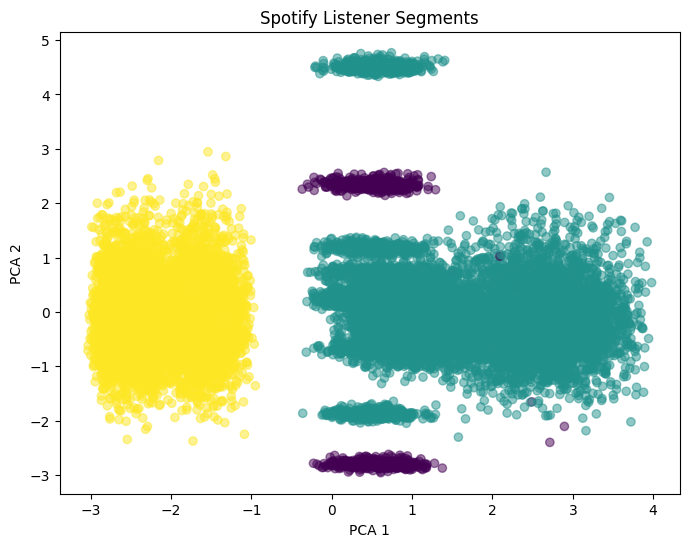

In [15]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df["cluster_3"], alpha=0.5)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Spotify Listener Segments")
plt.show()

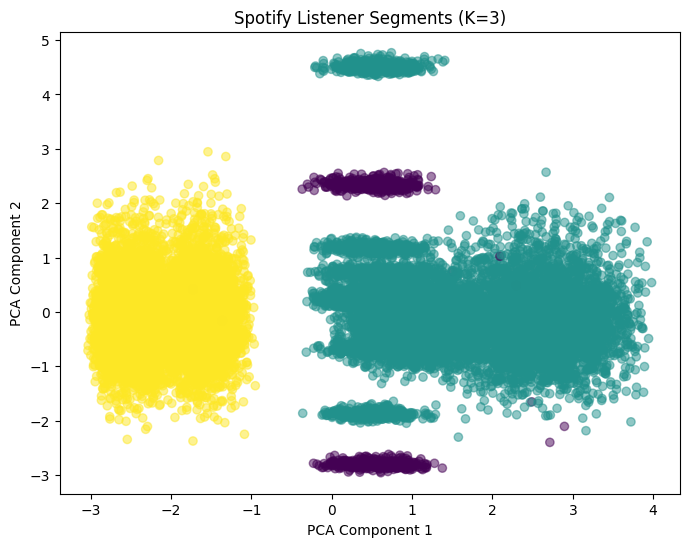

In [16]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce to 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot clusters
plt.figure(figsize=(8,6))
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df["cluster_3"],
    alpha=0.5
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Spotify Listener Segments (K=3)")
plt.show()